# CN calculation for wet and dry conditions using "Events Table Stratified" 


__Modification of Script__:

1. The rainfall is developed using Hydrology 2. And the hyetographs are developed using the NOAA Atlas 14 temporal distributions (four different quartiles).


2. To account for the spatial variability of the CNs within the basin, we calculate the CNs for wet and dry condition for each unique CN values within the basin.

    In Hydrology 3, for each return period, the original "Events Table Stratified" script calculates the average max potential retention value for upper 50% and lower      50%. These avg. S values are then converted to CN values for wet and dry conditions.  
    The conversion is done using the formula: S = 1000/CN - 10
    
    These CN values for wet and dry conditions are then provided as an input to the HEC-RAS model. This way the RAS model acccounts for the spatial variability of the      losses associated with different land use conditions throughout the basin.
    
    All the other calculation steps are same as described in the original "Events Stratified Table" script.




##

__Description__: 

A stratified sampling of runoff events is performed on a runoff distribution derived from 
- Rainfall distribution based on the NOAA Atlas 14 (or mean precipitation curve) data (area averaged) and
- Max. potential retention distribution based on a beta distribution.

The rainfall distribution is assumed to be represented by a generalized extreme value distribution (GEV). This GEV distribution is fitted to the data (NOAA Atlas 14 data or corresponding values for the mean precipitation curve). The maximum potential distribution variabilitity corresponds to the curve number (CN) dispersion documented by the NRCS. For the rainfall distribution and runoff distribution, this notebook sequentially calculates 
- GEV distribution parameters for the NOAA or mean precipitation curve data
- Rainfall values and probability weights for different return period events
- Max potential retention variability and distribution parameters
- Partition for the max potential distribution for calculating the runoff distribution
- Runoff as a function of the return interval (i.e., return period)
- Runoff event probability weights
- A stratified sampling of runoff, where for each return interval the sampling includes
    - Event weight
    - Runoff value
    - Max. potential retention value
    - Rainfall value




__Input__: 
- Parameters: curve number and initial abstraction ratio; the probable maximum precipitation; return intervals for stratified sampling; maximum return interval limit for the stratified sampling bins;  the volume, region, and duration ([See map for volume and region](https://hdsc.nws.noaa.gov/hdsc/pfds/pfds_temporal.html)).
        
- The area averaged precipitation frequency data for the specified duration.

- `DataRepository` folder which contains the following:
    - The *NEH630_Table_10_1.json* which contains information about the spread of possible values around the provided (expected) curve number. [Source](https://www.wcc.nrcs.usda.gov/ftpref/wntsc/H&H/NEHhydrology/ch10.pdf).


__Output__: This script gives the wet and dry condition CN values for each unique CN value within a basin.

---
## Load Libraries, Parameters, and Data:
### Libraries:

In [1]:
import sys
sys.path.append('../../core')
from hydromet import*
from hydromet_stratified import*
import hydromet_JSON_to_DSS
import mean_frequency_curve
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
%matplotlib inline

### Parameters: 
#### Local (site specific):

In [2]:
## Excess rainfall parameters:
#CN  = 93  # Curve number, must be an integer
# Commenting out CN because later in the code, we will loop for all the unique values of CN from a basin

mu  = 0.2  # Intial abstraction ratio parameter
PMP = 31.02  # [inches]; Probable maximum precipitation for the selected duration 
Return_Intervals = np.array([2, 5, 10, 25, 50, 100, 200, 500, 1000, 2000, 3000])  # Return intervals for calculating runoff values.
RI_upper_bound = 3700  # Upper Limit of recurrence interval evaluation, suggest not changing this value
lower_limit = 1 # Lower limit of NOAA Atlas 14 precipitation values
Aerial_Reduction = 1  # Aerial reduction factor
duration = 12  # [hours]; Event duration;  must be a duration in the input Precip_Table file
Time_Extend = 12.0 # Model run time extension beyond the hyetograph (24-hour) period.
hydrology_IDs = [1, 2, 3, 4]  # ID's of the different hydrology scenarios considered. 


## Mean curve parameters:
return_intervals_mc = np.array([1.01, 1.05, 1.11, 1.25, 20, 2000, 5000, 10000, 20000, 50000, 100000, 200000, 1/2E-06, 1/1E-06, 1/5E-07, 1/2E-07, 1/1E-07]) # Additional return intervals for the mean curve inputs
CL = np.array([0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 0.995, 0.999]) # Confidence limits

## Integration parameter:
n_partition = 30  # Define number of partitions of max potential retention distribution; this controls the resolution of the integration of int p(Q|S)p(S) dS

## Filenames and paths:
Project_Area = 'CaptainCreek'          # Project area name
Pluvial_Model = 'P01'                # Pluvial model name
BCN = 'CaptainCreek'               # Domain/boundary condition name 071200040505 Kansas 102500170609 Nevada '160600140303'

precip_table = '{0}_{1}_{2}_PrecipTable.xlsx'.format(Project_Area, Pluvial_Model, BCN)  # NOAA Data
precip_mean_curve_input_table = f'Mean_Curve_Input_{Project_Area}.csv'
precip_mean_curve_table = f'MeanCurve_{Project_Area}.csv'
CN_Distribution = 'NEH630_Table_10_1.json'
nrcs_precip_table = '{0}_{1}_{2}_nrcs_PrecipTable.xlsx'.format(Project_Area, Pluvial_Model, BCN)  # NRCS Data
atlas14_precip_table = '{0}_{1}_{2}_atlas_temporal_PrecipTable.xlsx'.format(Project_Area, Pluvial_Model, BCN)  # Atlas 14 Temporal Data

root_dir = pl.Path(os.getcwd())
outputs_dir = root_dir/'Outputs'
precip_table_dir = outputs_dir/precip_table
nrcs_precip_table_dir = outputs_dir/nrcs_precip_table   
atlas14_precip_table_dir = outputs_dir/atlas14_precip_table 
precip_mean_curve_input_table_dir = outputs_dir/precip_mean_curve_input_table
precip_mean_curve_table_dir = outputs_dir/precip_mean_curve_table
datarepository_dir = root_dir.parent.parent/'DataRepository'
bin_dir = root_dir.parent.parent/'bin'

## Options:
display_print = False

## Options:
save_dss = False
remove_ind_dur = True                              # Remove individual duration files which are combined at the end of this notebook
run_dur_dic = {'12': 1, '12': 1, '12': 1, '12': 1}  # Run durations in days

##### Convert all paths to objects:

In [3]:
outputs_dir = pl.Path(outputs_dir)
precip_table_dir = pl.Path(precip_table_dir)
precip_mean_curve_input_table_dir = pl.Path(precip_mean_curve_input_table_dir)
precip_mean_curve_table_dir = pl.Path(precip_mean_curve_table_dir)
datarepository_dir = pl.Path(datarepository_dir)

### Data:
#### NOAA Atlas 14 precipitation values:

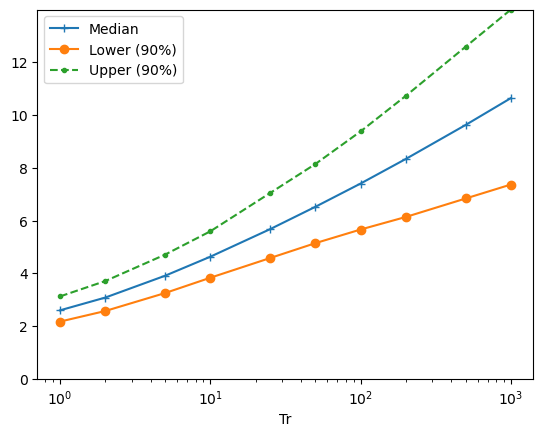

,Median,Lower (90%),Upper (90%)
Tr,,,
1,2.604981,2.177986,3.130930
2,3.087570,2.578846,3.712869
5,3.913869,3.258836,4.713785
10,4.634435,3.838935,5.595967
25,5.678346,4.584336,7.046542
50,6.524192,5.148056,8.143822
100,7.405813,5.664374,9.379533
200,8.336808,6.139958,10.726243
500,9.624182,6.839075,12.586257


In [4]:
raw_precip = get_input_data(precip_table_dir, duration, lower_limit, display_print)
raw_precip.rename(columns = {'Expected Value': 'Median'}, inplace = True)
raw_precip.plot(style=['+-','o-','.--'], logx=True, ylim=(0, raw_precip['Upper (90%)'].max()))
plt.show()
raw_precip
#raw_precip.head(2)

#### Fit GEV to rainfall data (find GEV parameters):

In [5]:
## Reduce precipitation by aerial reduction factor:
raw_precip_reduced = raw_precip[raw_precip.select_dtypes(include=['number']).columns]*Aerial_Reduction

## Find GEV parameter values:
df_GEV_parameters_M = GEV_parameters_Fit(raw_precip_reduced, 'Median', PMP)
df_GEV_parameters_U = GEV_parameters_Fit(raw_precip_reduced, 'Upper (90%)', PMP)
df_GEV_parameters_L = GEV_parameters_Fit(raw_precip_reduced, 'Lower (90%)', PMP)
df_GEV_parameters = pd.concat([df_GEV_parameters_M, df_GEV_parameters_L, df_GEV_parameters_U], axis=1)
df_GEV_parameters

C:\_code\Probabilistic_CaptainKill\pfra_captainkill\notebooks\pluvial\../../core\hydromet_stratified.py:62: RuntimeWarning:

divide by zero encountered in scalar divide



,GEV Median,GEV Lower (90%),GEV Upper (90%)
mu,2.943347,2.458489,3.531619
sigma,0.669144,0.615418,0.800181
xi,-0.143483,-0.044163,-0.178357


---
## Hydrology 2

### Mean Curve Calculation
#### Data for calculating the mean curve:

In [6]:
return_interval_Data = return_interval_data(raw_precip_reduced, return_intervals_mc, df_GEV_parameters, PMP)
return_interval_Data
#return_interval_Data.head(2)

,Median,Lower (90%),Upper (90%),Log SD (Lower),Log SD (Upper),Max Log SD,mu LN
1.00,2.604981,2.177986,3.130930,0.108830,0.111796,0.111796,0.957425
1.01,2.024497,1.548387,2.460576,0.162983,0.118586,0.162983,0.705321
1.05,2.254817,1.789889,2.723616,0.140374,0.114828,0.140374,0.813069
1.11,2.415030,1.952222,2.908799,0.129328,0.113087,0.129328,0.881712
1.25,2.635539,2.168677,3.166531,0.118523,0.111580,0.118523,0.969088
2.00,3.087570,2.578846,3.712869,0.109448,0.112110,0.112110,1.127384
5.00,3.913869,3.258836,4.713785,0.111341,0.113048,0.113048,1.364526
10.00,4.634435,3.838935,5.595967,0.114480,0.114609,0.114609,1.533514
20.00,5.421474,4.411707,6.665005,0.125292,0.125534,0.125534,1.690368
25.00,5.678346,4.584336,7.046542,0.130100,0.131232,0.131232,1.736660


#### Input for calculating the mean curve:

In [7]:
mean_curve_data = mean_curve_input_table(CL, return_interval_Data, PMP, precip_mean_curve_input_table_dir)
mean_curve_data.head(2)

,0.001,0.005,0.010,0.050,0.100,0.200,0.300,0.400,0.500,0.600,0.700,0.800,0.900,0.950,0.990,0.995,0.999
AEP,,,,,,,,,,,,,,,,,
1.000000e-07,24.096486,25.517422,26.162161,27.741252,28.458799,29.200277,29.645513,29.966707,30.218927,30.427034,30.604424,30.759163,30.896489,30.959791,31.008191,31.014110,31.018824
2.000000e-07,23.243043,24.809774,25.525787,27.292690,28.101710,28.941682,29.447984,29.814122,30.102155,30.340156,30.543273,30.720638,30.878186,30.950855,31.006436,31.013234,31.018649


##### Calculate the mean precipitation curve:

Specified inputs_path is to a csv, loaded table.

Values increase with decreasing annual exceedance probability for all confidence limits as expected



C:\_code\Probabilistic_CaptainKill\pfra_captainkill\notebooks\pluvial\../../core\meanffc.py:496: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



,P_Mean_in,P_Median_in
AEP,,
0.9,2.326064,2.417473
0.5,3.152734,3.087570


C:\_code\Probabilistic_CaptainKill\pfra_captainkill\notebooks\pluvial\Outputs - already exists



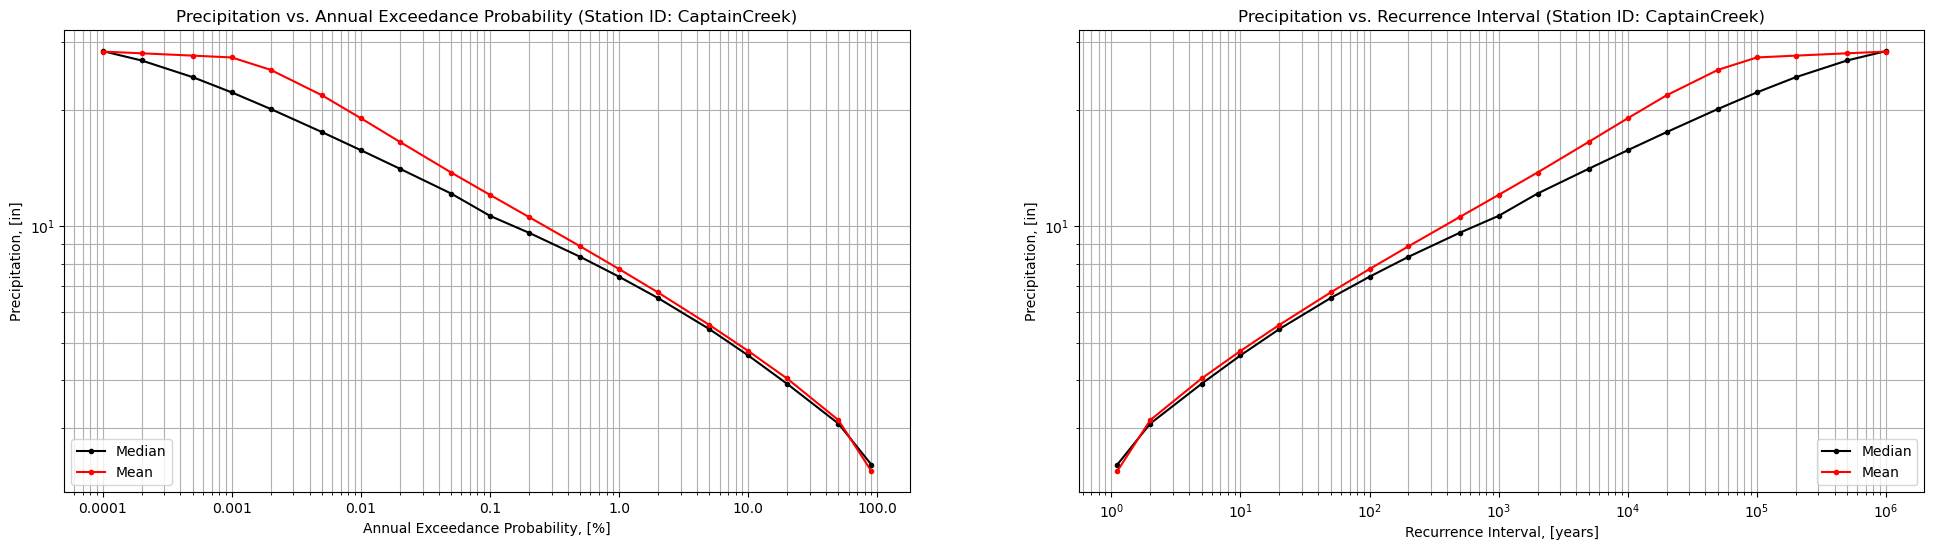

In [8]:
df = mean_frequency_curve.main(Project_Area, precip_mean_curve_input_table_dir, outputs_dir, data_type = 'P', round_decimals = 6)
plt.show()

---
### Load Mean Curve:

In [9]:
mean_curve_precip = pd.read_csv(precip_mean_curve_table_dir, index_col=0)
mean_curve_precip['Tr'] = 1.0/mean_curve_precip.index.values
mean_curve_precip.set_index('Tr', inplace = True)
mean_curve_precip.plot(style=['+-', 'o-'], logx=True, ylim=(0, PMP))
mean_curve_precip.head(2)

,P_Mean_in,P_Median_in
Tr,,
1.111111,2.326064,2.417473
2.000000,3.152734,3.087570


### Fit GEV to Mean Precipication Curve (Find GEV Parameters):

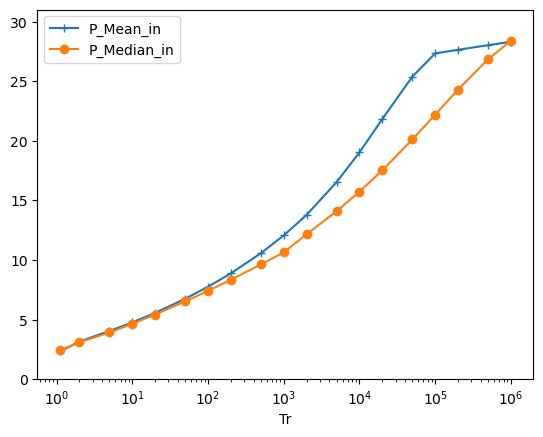

In [10]:
fit_values_mean_curve_precip = mean_curve_precip[1:20000] # Only fit the value up to about the 20,000 year event
df_GEV_parameters_E = GEV_parameters_Fit(fit_values_mean_curve_precip, 'P_Mean_in', PMP)
GEV_parameters_E = df_GEV_parameters_E.values.transpose()[0]
df_GEV_parameters = pd.concat([df_GEV_parameters, df_GEV_parameters_E], axis=1)
df_GEV_parameters
plt.show()

#### Plot fitted GEV distribution and mean precipitation curve:

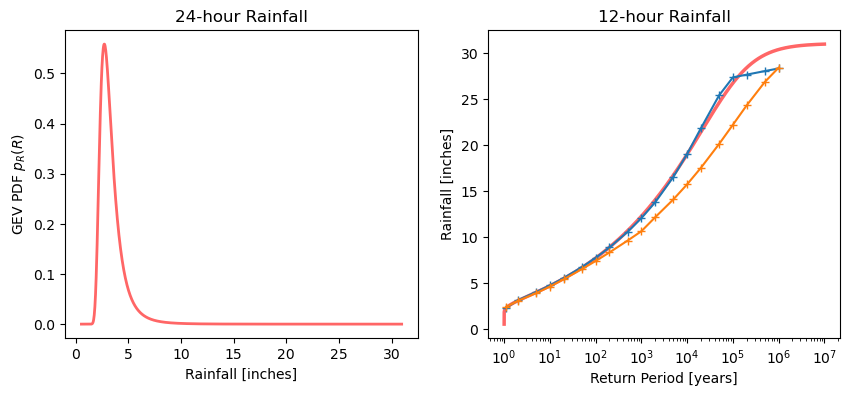

In [11]:
plot_GEV_precip_curves(mean_curve_precip, df_GEV_parameters_E, PMP, 'Rainfall')
plt.show()

### Using mean precipitation calculated in Hydrology 2 and leveraging it to generate Hydrology 4 hyetographs
We are using the mean precipitation developed in Hydrology 2. And the hyetographs are developed using the NOAA Atlas 14 temporal distributions (i.e., four different quartiles) instead of using the nested hyetograph.
#### Hydrology 2 Events:

In [12]:
df_weights_rainfall = weights_Rainfall(Return_Intervals, GEV_parameters_E, PMP, RI_upper_bound, mean_curve_precip, 'P_Mean_in', mu)
df_weights_rainfall.head(2)

,Bin Floor,Bin Ceiling,Event Weight,P_Mean_in
2.0,1.264491,4.091633,0.546431,3.152734
5.0,4.091633,6.292647,0.085486,4.039785


In [13]:
# Modified the function to create precip hyetograph using mean precip from Hydrology 2 and using 4 hyetographs for 4 quartiles NOAA data

def new_precip_to_runoff_h4(hydro_events:np.ndarray ,atlas14_precip_table_dir: pl.WindowsPath,
                     precip_data: pd.DataFrame,df_weights_rainfall: pd.DataFrame, display_print = False) -> tuple:
    """Takes the events, precipitation data, and atlas 14 temporal distribution to obtain a precip hyetograph for each recurrence interval. 
    """  
    Atlas14_hyetographs = ['q1', 'q2', 'q3', 'q4']
    hydro_events = list(np.int64(df_weights_rainfall.index))
    column_names = []
    for event in hydro_events:
        for hyetograph in Atlas14_hyetographs:
            column_names.append(str(event)+'_'+hyetograph)
            
    prep_curves = pd.DataFrame(columns = column_names)
    prep_weights = pd.DataFrame(index = column_names, columns= ['Event Weight'])
    
    for  hyetograph in  Atlas14_hyetographs:
        for event in hydro_events:
            dist_df, weight_df = get_hyeto_input_data_atlas(atlas14_precip_table_dir, hyetograph, display_print)
            dist_df['precip'] = dist_df[hyetograph]*df_weights_rainfall['P_Mean_in'].loc[event]
            dist_df['hyeto_input'] = dist_df['precip'].diff()
            dist_df['hyeto_input'] = dist_df['hyeto_input'].fillna(0.0)
            prep_curves[str(event)+'_'+hyetograph] = dist_df['hyeto_input']
            prep_weights['Event Weight'].loc[str(event)+'_'+hyetograph] = df_weights_rainfall['Event Weight'][event]*weight_df['weight'][hyetograph]
    return prep_curves, prep_weights

#### Hydrology 4 Runoff Forcing Data:

In [14]:
# precip hyetograph data by applying the above modified function
RI_list = np.array2string(np.sort(df_weights_rainfall.index.to_numpy()))
prep_curves, prep_weights = new_precip_to_runoff_h4(RI_list,atlas14_precip_table_dir,df_weights_rainfall,df_weights_rainfall)
final_curves = extend_time(prep_curves,Time_Extend,0.5)

In [15]:
# event weights saving as csv
prep_weights.to_csv(f'event_weights_{Project_Area}.csv')

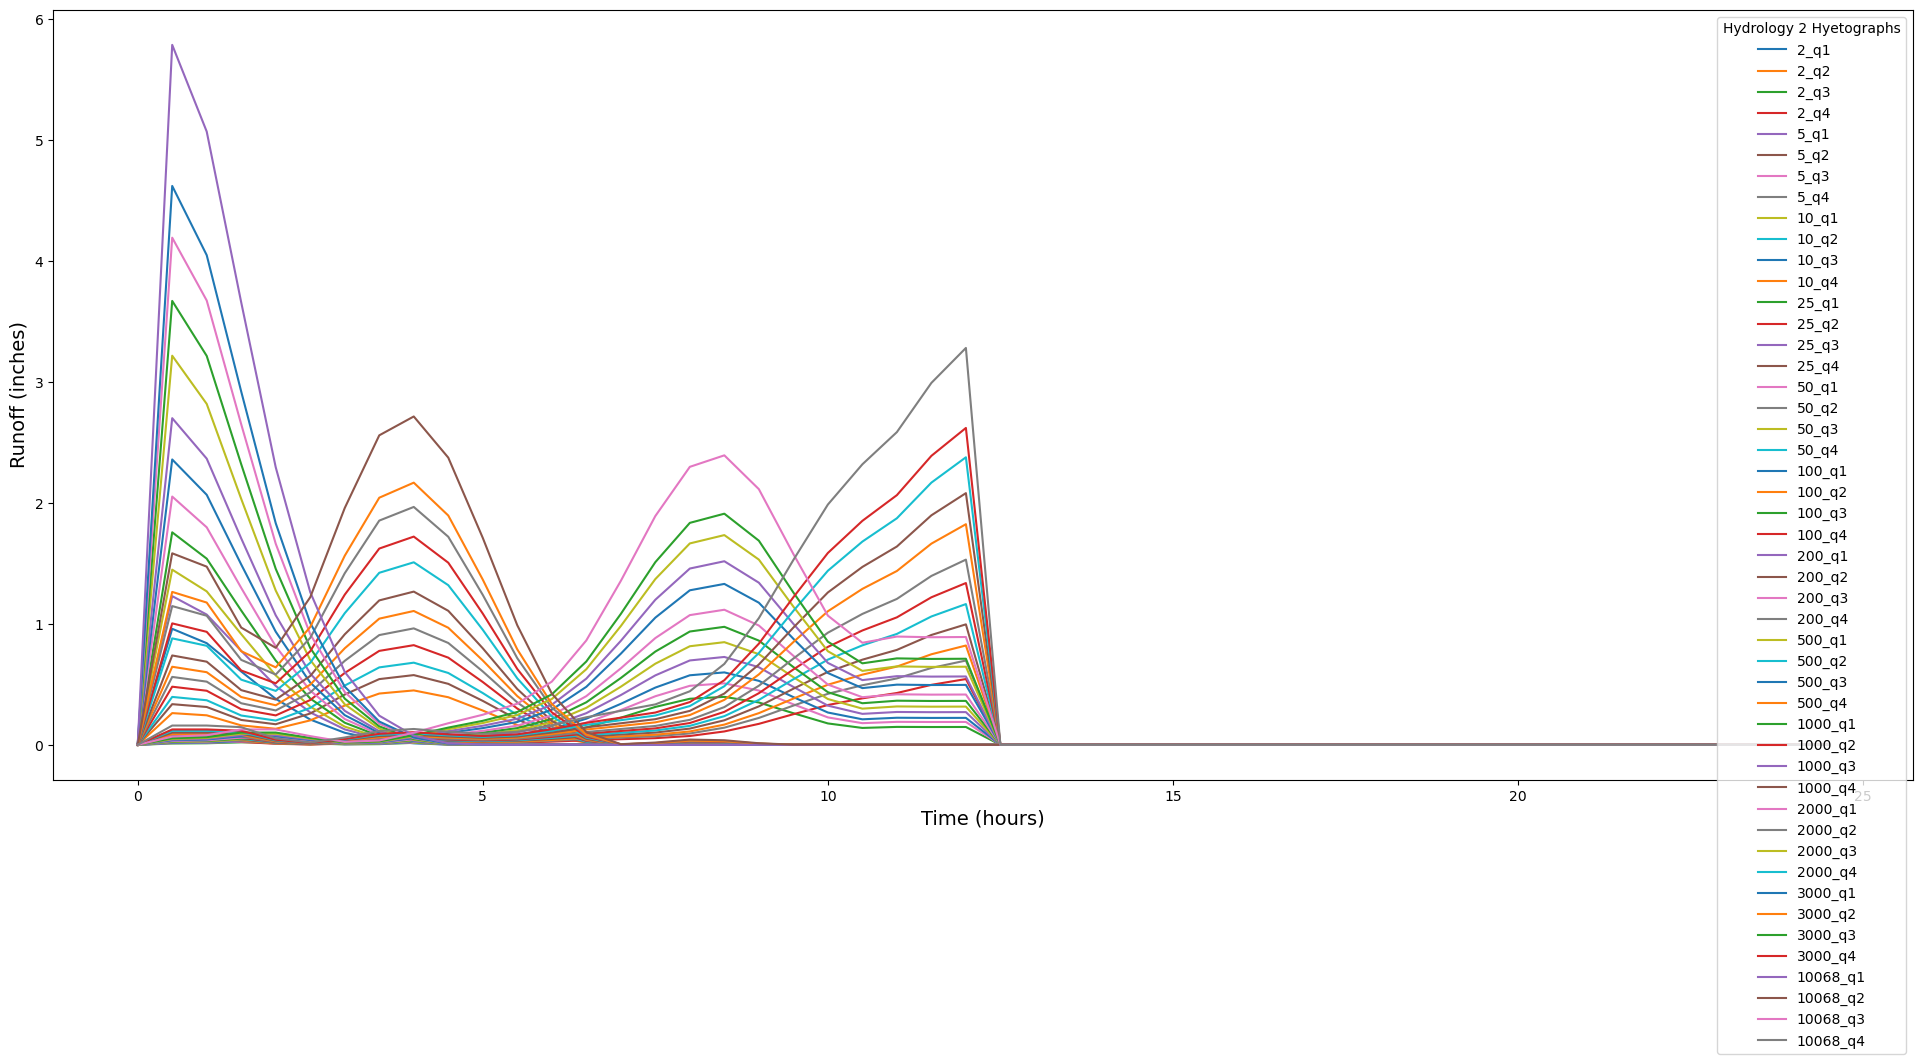

In [16]:
# plotting the final plots with extended time
t_p = final_curves.plot(figsize=(24, 10))
t_p.legend(title='Hydrology 2 Hyetographs')
t_p.set_xlabel('Time (hours)', fontsize=14)
t_p.set_ylabel('Runoff (inches)', fontsize=14)
t_p.plot();
plt.show()

In [17]:
final_curves.head(2)

,2_q1,2_q2,2_q3,2_q4,5_q1,5_q2,5_q3,5_q4,10_q1,10_q2,...,2000_q3,2000_q4,3000_q1,3000_q2,3000_q3,3000_q4,10068_q1,10068_q2,10068_q3,10068_q4
hours,,,,,,,,,,,,,,,,,,,,,
0.0,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0.5,0.959692,0.262623,0.01135,0.026483,1.229711,0.336514,0.014543,0.033934,1.448672,0.396434,...,0.049597,0.115725,4.62168,1.264737,0.054659,0.127537,5.788236,1.583969,0.068455,0.159728


In [18]:
# Saving the rainfall hyetographs to individual csv
# Folder to save the rainfall hyetographs
hyet_output_dir = root_dir.parent.parent/'misc'
hyet_output_folder = hyet_output_dir/f'{Project_Area}_hyeto_inputs'
if not hyet_output_folder.exists(): hyet_output_folder.mkdir()

for year in final_curves.columns:
    hyet = final_curves[[year]]
    hyet.to_csv(hyet_output_folder/f"{year}.csv")
    print(f"Saved {year}.csv")

Saved 2_q1.csv
Saved 2_q2.csv
Saved 2_q3.csv
Saved 2_q4.csv
Saved 5_q1.csv
Saved 5_q2.csv
Saved 5_q3.csv
Saved 5_q4.csv
Saved 10_q1.csv
Saved 10_q2.csv
Saved 10_q3.csv
Saved 10_q4.csv
Saved 25_q1.csv
Saved 25_q2.csv
Saved 25_q3.csv
Saved 25_q4.csv
Saved 50_q1.csv
Saved 50_q2.csv
Saved 50_q3.csv
Saved 50_q4.csv
Saved 100_q1.csv
Saved 100_q2.csv
Saved 100_q3.csv
Saved 100_q4.csv
Saved 200_q1.csv
Saved 200_q2.csv
Saved 200_q3.csv
Saved 200_q4.csv
Saved 500_q1.csv
Saved 500_q2.csv
Saved 500_q3.csv
Saved 500_q4.csv
Saved 1000_q1.csv
Saved 1000_q2.csv
Saved 1000_q3.csv
Saved 1000_q4.csv
Saved 2000_q1.csv
Saved 2000_q2.csv
Saved 2000_q3.csv
Saved 2000_q4.csv
Saved 3000_q1.csv
Saved 3000_q2.csv
Saved 3000_q3.csv
Saved 3000_q4.csv
Saved 10068_q1.csv
Saved 10068_q2.csv
Saved 10068_q3.csv
Saved 10068_q4.csv



## Hydrology 3 (Modified to calculate CN values for dry and wet condition):
### Retrieve Max Potential Retention Variability and Distribution Parameters:

#### This chunk of code (the 2 lines that are below this comment) is based on Hydrology 3. For each CN value, it extracts wet and dry soil moisture conditions, and fits into a beta distribution.

Steps involved:
1. First, all the unique Curve Number (CN) values are extracted from the basin. This is done such that we can account for the spatial variability of the CNs within a basin. Eventually, we will have wet and dry condition CN values for all the unique CNs within the basin.
2. For each unique CN value, the similar process as in Hydrology 3 is conducted. Here, for each CN, it extracts wet and dry soil moisture condition, and then fits into a beta distribution.
3. Then, the runoff data is fitted into a GEV distribution.
4. For each Return Period, the average maximum potential retention (S) values are calculated for lower 50% and upper 50%.
5. These two "S" values for each Return Period are then converted into CN by using the formula: S = 1000/CN - 10
6. In this way, we will have two sets of CN values for wet and dry conditions for each of the Return Periods. The CN values thus obtained are spatially varied instead of a single average CN value for the entire watershed.


These CN values for wet and dry conditions are then provided as an input to the HEC-RAS model. This way the RAS model acccounts for the spatial variability of the losses associated with different land use conditions throughout the basin.

In [19]:
# manually providing the list of unique CN values
#unique_cn_list = [36,39,56,57,60,61,63,64,67,69,70,73,74,75,77,78,79,80,81,82,83,85,86,88,89,90,92,93,98] #Captain
#unique_cn_list = [56,57,60,61,63,64,69,70,73,74,75,77,78,79,80,81,82,83,85,86,88,89,90,92,93,98] #Kill
#unique_cn_list = [36,39,56,57,60,61,63,64,67,69,70,73,74,75,77,78,79,80,81,82,83,85,86,88,89,90,92,93,98]
unique_cn_list = [36,39,56,57] #,60,61,63,64,67,69,70,73,74,75,77]

In [21]:
'''The cells below are utilized to calculate the CN values based on the conditional probability explained further in description and report.
They are operated in chunks of 7-8 unique CNs at one time in order to avoid the loop stucking due to some reasons that needs to be
looked into detail. Right now, this is the workaround for it.'''

'The cells below are utilized to calculate the CN values based on the conditional probability explained further in description and report.\nThey are operated in chunks of 7-8 unique CNs at one time in order to avoid the loop stucking due to some reasons that needs to be\nlooked into detail. Right now, this is the workaround for it.'

In [21]:
# List of unique CN values in the basin
CN = unique_cn_list
df_weights_rainfall = {} # a dictionary to store dataframes that will be created for each CN

## Define probability for each partition of the max potential retention distribution:
Delta_P = 1.0/n_partition

# Looping for all the CNs
for i in range(len(CN)):
    
    ## NRCS value of wet and dry soil moiture conditions:
    arc_data = get_CN_distribution(datarepository_dir, CN_Distribution, CN[i], display_print)
    
    ## Table of wet, dry, and average (or median) soil moisture conditions:
    df_CN = prep_cn_table(CN[i], arc_data)  
    
    ## Table of parameters for best fit of beta-type distribution to NRCS estiamted dispersion:
    fitted_cn = find_optimal_curve_beta_dist_S_updated(df_CN)
    fitted_cn['mu'] = mu

    #print(fitted_cn)
    
    ## Distribution parameter values:
    S_limit = 1000.0/fitted_cn.iloc[0]['CN Lower Limit']-10.0
    alpha = fitted_cn.iloc[0]['alpha']
    beta = fitted_cn.iloc[0]['beta']
    
    ## Find the average value over each partition, which is the basis for the runoff distribution:
    partition_avg = partition_S_avgs(n_partition, Delta_P, alpha, beta, S_limit)
    
    #########################################################################################
    
    
    
    ## Error between the integral approach (based on summation integration) and the actual value:
    error_PQ = 1-CDF_Q(PMP, mu, alpha, beta, S_limit, GEV_parameters_E, PMP, partition_avg, Delta_P, 0)
    
    
    # Fit GEV to runoff data (find GEV parameters)
    df_runoff, df_GEV_parameters_R = runoff_GEV(mu, GEV_parameters_E, PMP, alpha, beta, S_limit, partition_avg, Delta_P, error_PQ)
    GEV_parameters_R = df_GEV_parameters_R.values.transpose()[0]
    
    
    # Runoff weights
    df_weights_runoff = runoff_weights(Return_Intervals, RI_upper_bound, mu, GEV_parameters_R,  GEV_parameters_E, PMP, partition_avg, Delta_P, error_PQ)
    
    # Calculate runoff and corresponding max potential retention and rainfall (average and median)
    df_runoff_SR1 = Scenarios_Avg_S_Median_S(df_weights_runoff, mu, GEV_parameters_E, PMP, partition_avg, Delta_P, alpha, beta, S_limit, error_PQ)
    
    # Calculate lower 50% and upper 50% max potential retention and rainfall
    df_runoff_SR2 = Scenarios_low_and_high_S(df_runoff_SR1, mu, GEV_parameters_E, PMP, partition_avg, Delta_P, alpha, beta, S_limit, error_PQ)
    
    
    # Formatting the data
    hydro_events_orig = list(df_runoff_SR2.index)
    relabel_U = [str(hyetograph)+'_U' for hyetograph in hydro_events_orig]
    relabel_L = [str(hyetograph)+'_L' for hyetograph in hydro_events_orig]
    
    df_runoff_SR2_U = df_runoff_SR2[['Event Weight', 'Runoff', 'Avg. S (Upper 50%)', 'Rainfall (Upper 50%)']].copy()
    df_runoff_SR2_U.rename(columns = {'Avg. S (Upper 50%)': 'Avg. S', 'Rainfall (Upper 50%)': 'Rainfall'}, inplace = True)
    df_runoff_SR2_U.index = relabel_U
    
    df_runoff_SR2_L = df_runoff_SR2[['Event Weight', 'Runoff', 'Avg. S (Lower 50%)',  'Rainfall (Lower 50%)']].copy()
    df_runoff_SR2_L.rename(columns = {'Avg. S (Lower 50%)': 'Avg. S', 'Rainfall (Lower 50%)': 'Rainfall'}, inplace = True)
    df_runoff_SR2_L.index = relabel_L
    
    df_weights_rainfall[i] = pd.concat([df_runoff_SR2_U, df_runoff_SR2_L]).sort_values(by=['Runoff'])


    # Adding original CN values
    df_weights_rainfall[i]['CN_original'] = CN[i]
    
    # Calculate CN values for wet and dry conditions by using lower 50% and upper 50% max potential retention values
    CN_upd = np.int64(1000/(df_weights_rainfall[i]['Avg. S']+10))
    df_weights_rainfall[i]['CN_updated'] = CN_upd

    print(fitted_cn)

C:\Users\dneupane\.conda\envs\pfra2clone\Lib\site-packages\scipy\optimize\_slsqp_py.py:437: RuntimeWarning:

Values in x were outside bounds during a minimize step, clipping to bounds

C:\_code\Probabilistic_CaptainKill\pfra_captainkill\notebooks\pluvial\../../core\hydromet_stratified.py:62: RuntimeWarning:

divide by zero encountered in scalar divide



   AMC I (Dry)  AMC II  AMC III (Wet)    alpha      beta  CN Lower Limit  \
1           19      36             56  1.91002  3.755273       12.254359   

   Fitted AMC I (Dry)  Fitted AMC II  Fitted AMC III (Wet)   mu  
1           19.000001      36.000014             55.999948  0.2  


C:\Users\dneupane\.conda\envs\pfra2clone\Lib\site-packages\scipy\optimize\_slsqp_py.py:437: RuntimeWarning:

Values in x were outside bounds during a minimize step, clipping to bounds

C:\_code\Probabilistic_CaptainKill\pfra_captainkill\notebooks\pluvial\../../core\hydromet_stratified.py:62: RuntimeWarning:

divide by zero encountered in scalar divide



   AMC I (Dry)  AMC II  AMC III (Wet)     alpha      beta  CN Lower Limit  \
1           21      39             59  1.924457  3.857047       13.517201   

   Fitted AMC I (Dry)  Fitted AMC II  Fitted AMC III (Wet)   mu  
1           20.999996       39.00001             58.999955  0.2  


C:\Users\dneupane\.conda\envs\pfra2clone\Lib\site-packages\scipy\optimize\_slsqp_py.py:437: RuntimeWarning:

Values in x were outside bounds during a minimize step, clipping to bounds

C:\_code\Probabilistic_CaptainKill\pfra_captainkill\notebooks\pluvial\../../core\hydromet_stratified.py:62: RuntimeWarning:

divide by zero encountered in scalar divide



   AMC I (Dry)  AMC II  AMC III (Wet)     alpha      beta  CN Lower Limit  \
1           36      56             75  1.849381  3.085625       26.917836   

   Fitted AMC I (Dry)  Fitted AMC II  Fitted AMC III (Wet)   mu  
1           36.000011      55.999989             74.999929  0.2  


C:\Users\dneupane\.conda\envs\pfra2clone\Lib\site-packages\scipy\optimize\_slsqp_py.py:437: RuntimeWarning:

Values in x were outside bounds during a minimize step, clipping to bounds

C:\_code\Probabilistic_CaptainKill\pfra_captainkill\notebooks\pluvial\../../core\hydromet_stratified.py:62: RuntimeWarning:

divide by zero encountered in scalar divide



   AMC I (Dry)  AMC II  AMC III (Wet)     alpha      beta  CN Lower Limit  \
1           37      57             75  1.986328  3.639022       26.505361   

   Fitted AMC I (Dry)  Fitted AMC II  Fitted AMC III (Wet)   mu  
1           36.999984      57.000014             75.000003  0.2  


In [22]:
df_weights_rainfall

{0:          Event Weight     Runoff     Avg. S   Rainfall  CN_original  \
 2_U          0.278761   0.145552  15.445092   4.662912           36   
 2_L          0.278761   0.145552   8.251264   2.821337           36   
 5_U          0.041251   0.500760  12.719259   5.330369           36   
 5_L          0.041251   0.500760   5.227455   2.933061           36   
 10_U         0.054303   0.802156   9.471854   5.080906           36   
 10_L         0.054303   0.802156   4.162553   3.104386           36   
 25_U         0.011212   1.279809   7.702109   5.384496           36   
 25_L         0.011212   1.279809   3.007412   3.304974           36   
 50_U         0.008659   1.720533   8.270026   6.383239           36   
 50_L         0.008659   1.720533   2.143640   3.393338           36   
 100_L        0.002050   2.247470   1.533485   3.600511           36   
 100_U        0.002050   2.247470   9.167937   7.633587           36   
 200_L        0.002723   2.879176   1.282477   4.097102      

In [23]:
# Dictionary to store the new dataframes for individual events, for e.g. 2_U, 2_L and so on. Basically rearranging the updated CN values based on individual events
event_dfs = {}

# Iterating over each dataframe (i.e., for each event) in df_weights_rainfall
for key, df in df_weights_rainfall.items():
    for event in df.index.unique():  # Extracting unique index values as the return periods are stored as index
        if event not in event_dfs:
            event_dfs[event] = pd.DataFrame()
        event_dfs[event] = pd.concat([event_dfs[event], df.loc[[event]]])  # Selecting rows by index

# Assign each dataframe a variable dynamically (optional)
globals().update(event_dfs)

event_dfs

{'2_U':      Event Weight    Runoff     Avg. S  Rainfall  CN_original  CN_updated
 2_U      0.278761  0.145552  15.445092  4.662912           36          39
 2_U      0.278258  0.166534  14.712476  4.593263           39          40
 2_U      0.275465  0.363075  10.224481  4.161689           56          49
 2_U      0.275522  0.367287  10.006051  4.110684           57          49,
 '2_L':      Event Weight    Runoff    Avg. S  Rainfall  CN_original  CN_updated
 2_L      0.278761  0.145552  8.251264  2.821337           36          54
 2_L      0.278258  0.166534  7.891006  2.810839           39          55
 2_L      0.275465  0.363075  5.610579  2.742410           56          64
 2_L      0.275522  0.367287  5.559204  2.736161           57          64,
 '5_U':      Event Weight    Runoff     Avg. S  Rainfall  CN_original  CN_updated
 5_U      0.041251  0.500760  12.719259  5.330369           36          44
 5_U      0.041380  0.553734  11.867259  5.228682           39          45
 5_U   

In [24]:

unique_cn_list = [60,61,63,64,67] #,69,70,73,74,75,77]
# List of unique CN values in the basin
CN = unique_cn_list
df_weights_rainfall = {} # a dictionary to store dataframes that will be created for each CN

## Define probability for each partition of the max potential retention distribution:
Delta_P = 1.0/n_partition

# Looping for all the CNs
for i in range(len(CN)):
    
    ## NRCS value of wet and dry soil moiture conditions:
    arc_data = get_CN_distribution(datarepository_dir, CN_Distribution, CN[i], display_print)
    
    ## Table of wet, dry, and average (or median) soil moisture conditions:
    df_CN = prep_cn_table(CN[i], arc_data)  
    
    ## Table of parameters for best fit of beta-type distribution to NRCS estiamted dispersion:
    fitted_cn = find_optimal_curve_beta_dist_S_updated(df_CN)
    fitted_cn['mu'] = mu

    #print(fitted_cn)
    
    ## Distribution parameter values:
    S_limit = 1000.0/fitted_cn.iloc[0]['CN Lower Limit']-10.0
    alpha = fitted_cn.iloc[0]['alpha']
    beta = fitted_cn.iloc[0]['beta']
    
    ## Find the average value over each partition, which is the basis for the runoff distribution:
    partition_avg = partition_S_avgs(n_partition, Delta_P, alpha, beta, S_limit)
    
    #########################################################################################
    
    
    
    ## Error between the integral approach (based on summation integration) and the actual value:
    error_PQ = 1-CDF_Q(PMP, mu, alpha, beta, S_limit, GEV_parameters_E, PMP, partition_avg, Delta_P, 0)
    
    
    # Fit GEV to runoff data (find GEV parameters)
    df_runoff, df_GEV_parameters_R = runoff_GEV(mu, GEV_parameters_E, PMP, alpha, beta, S_limit, partition_avg, Delta_P, error_PQ)
    GEV_parameters_R = df_GEV_parameters_R.values.transpose()[0]
    
    
    # Runoff weights
    df_weights_runoff = runoff_weights(Return_Intervals, RI_upper_bound, mu, GEV_parameters_R,  GEV_parameters_E, PMP, partition_avg, Delta_P, error_PQ)
    
    # Calculate runoff and corresponding max potential retention and rainfall (average and median)
    df_runoff_SR1 = Scenarios_Avg_S_Median_S(df_weights_runoff, mu, GEV_parameters_E, PMP, partition_avg, Delta_P, alpha, beta, S_limit, error_PQ)
    
    # Calculate lower 50% and upper 50% max potential retention and rainfall
    df_runoff_SR2 = Scenarios_low_and_high_S(df_runoff_SR1, mu, GEV_parameters_E, PMP, partition_avg, Delta_P, alpha, beta, S_limit, error_PQ)
    
    
    # Formatting the data
    hydro_events_orig = list(df_runoff_SR2.index)
    relabel_U = [str(hyetograph)+'_U' for hyetograph in hydro_events_orig]
    relabel_L = [str(hyetograph)+'_L' for hyetograph in hydro_events_orig]
    
    df_runoff_SR2_U = df_runoff_SR2[['Event Weight', 'Runoff', 'Avg. S (Upper 50%)', 'Rainfall (Upper 50%)']].copy()
    df_runoff_SR2_U.rename(columns = {'Avg. S (Upper 50%)': 'Avg. S', 'Rainfall (Upper 50%)': 'Rainfall'}, inplace = True)
    df_runoff_SR2_U.index = relabel_U
    
    df_runoff_SR2_L = df_runoff_SR2[['Event Weight', 'Runoff', 'Avg. S (Lower 50%)',  'Rainfall (Lower 50%)']].copy()
    df_runoff_SR2_L.rename(columns = {'Avg. S (Lower 50%)': 'Avg. S', 'Rainfall (Lower 50%)': 'Rainfall'}, inplace = True)
    df_runoff_SR2_L.index = relabel_L
    
    df_weights_rainfall[i] = pd.concat([df_runoff_SR2_U, df_runoff_SR2_L]).sort_values(by=['Runoff'])


    # Adding original CN values
    df_weights_rainfall[i]['CN_original'] = CN[i]
    
    # Calculate CN values for wet and dry conditions by using lower 50% and upper 50% max potential retention values
    CN_upd = np.int64(1000/(df_weights_rainfall[i]['Avg. S']+10))
    df_weights_rainfall[i]['CN_updated'] = CN_upd

    print(fitted_cn)

C:\Users\dneupane\.conda\envs\pfra2clone\Lib\site-packages\scipy\optimize\_slsqp_py.py:437: RuntimeWarning:

Values in x were outside bounds during a minimize step, clipping to bounds

C:\_code\Probabilistic_CaptainKill\pfra_captainkill\notebooks\pluvial\../../core\hydromet_stratified.py:62: RuntimeWarning:

divide by zero encountered in scalar divide



   AMC I (Dry)  AMC II  AMC III (Wet)     alpha      beta  CN Lower Limit  \
1           40      60             78  1.847719  3.047675       30.515637   

   Fitted AMC I (Dry)  Fitted AMC II  Fitted AMC III (Wet)   mu  
1           39.999993      60.000003             77.999987  0.2  


C:\Users\dneupane\.conda\envs\pfra2clone\Lib\site-packages\scipy\optimize\_slsqp_py.py:437: RuntimeWarning:

Values in x were outside bounds during a minimize step, clipping to bounds

C:\_code\Probabilistic_CaptainKill\pfra_captainkill\notebooks\pluvial\../../core\hydromet_stratified.py:62: RuntimeWarning:

divide by zero encountered in scalar divide



   AMC I (Dry)  AMC II  AMC III (Wet)     alpha      beta  CN Lower Limit  \
1           41      61             78  1.984235  3.607705       30.000578   

   Fitted AMC I (Dry)  Fitted AMC II  Fitted AMC III (Wet)   mu  
1           40.999996      61.000007             77.999967  0.2  


C:\Users\dneupane\.conda\envs\pfra2clone\Lib\site-packages\scipy\optimize\_slsqp_py.py:437: RuntimeWarning:

Values in x were outside bounds during a minimize step, clipping to bounds

C:\_code\Probabilistic_CaptainKill\pfra_captainkill\notebooks\pluvial\../../core\hydromet_stratified.py:62: RuntimeWarning:

divide by zero encountered in scalar divide



   AMC I (Dry)  AMC II  AMC III (Wet)    alpha      beta  CN Lower Limit  \
1           43      63             80  1.86272  3.122785        32.97715   

   Fitted AMC I (Dry)  Fitted AMC II  Fitted AMC III (Wet)   mu  
1           42.999987       62.99996             80.000013  0.2  


C:\Users\dneupane\.conda\envs\pfra2clone\Lib\site-packages\scipy\optimize\_slsqp_py.py:437: RuntimeWarning:

Values in x were outside bounds during a minimize step, clipping to bounds

C:\_code\Probabilistic_CaptainKill\pfra_captainkill\notebooks\pluvial\../../core\hydromet_stratified.py:62: RuntimeWarning:

divide by zero encountered in scalar divide



   AMC I (Dry)  AMC II  AMC III (Wet)     alpha     beta  CN Lower Limit  \
1           44      64             81  1.798283  2.89543       34.505514   

   Fitted AMC I (Dry)  Fitted AMC II  Fitted AMC III (Wet)   mu  
1           43.999911      64.000046             80.999842  0.2  


C:\Users\dneupane\.conda\envs\pfra2clone\Lib\site-packages\scipy\optimize\_slsqp_py.py:437: RuntimeWarning:

Values in x were outside bounds during a minimize step, clipping to bounds

C:\_code\Probabilistic_CaptainKill\pfra_captainkill\notebooks\pluvial\../../core\hydromet_stratified.py:62: RuntimeWarning:

divide by zero encountered in scalar divide



   AMC I (Dry)  AMC II  AMC III (Wet)     alpha      beta  CN Lower Limit  \
1           47      67             83  1.776297  2.874089        37.29136   

   Fitted AMC I (Dry)  Fitted AMC II  Fitted AMC III (Wet)   mu  
1           47.000022       67.00006             82.999927  0.2  


In [29]:
import pandas as pd

with pd.ExcelWriter(r"C:\_code\Probabilistic_CaptainKill\_misc\addn_event_results.xlsx", engine="openpyxl") as writer:
    for sheet_name, df in event_dfs.items():
        df.to_excel(writer, sheet_name=sheet_name, index=False)

### Remarks regarding the 12th event
There is one caveat to notice while using this approach. For each CN value, we get different Return periods and rainfall value for the 12th event. This is due to the fact that the Return Period and Rainfall for the 12th event is calculated based on the conditional probability of Runoff(Q) dependent on Max. potential retention (S). And since we have different CN values, we will have different distribution of max potential retention (S). As a result, we tend to get different return period values for each CN, which is shown in cell below.

However, since we are only interested in wet and dry condition Curve Numbers (CN), the different Return Period and Rainfall values will not impact our approach and the subsequent analysis. 
As for the rainfall and return period values, we are using the rainfall developed using Hydrology 2 approach. And Hydrology 2 produces a single value of rainfall and return period for the 12th event.

In [30]:
# listing the 12th event
list(event_dfs.items())[-10:]

[('9744_U',
          Event Weight     Runoff    Avg. S   Rainfall  CN_original  CN_updated
  9744_U      0.000135  17.031389  3.414907  20.630109           82          74),
 ('9744_L',
          Event Weight     Runoff    Avg. S   Rainfall  CN_original  CN_updated
  9744_L      0.000135  17.031389  1.066477  18.251628           82          90),
 ('9674_U',
          Event Weight     Runoff    Avg. S   Rainfall  CN_original  CN_updated
  9674_U      0.000135  17.136254  3.269212  20.598913           83          75),
 ('9674_L',
          Event Weight     Runoff    Avg. S   Rainfall  CN_original  CN_updated
  9674_L      0.000135  17.136254  0.959261  18.238953           83          91),
 ('9848_U',
          Event Weight     Runoff    Avg. S   Rainfall  CN_original  CN_updated
  9848_U      0.000135  17.596356  2.693223  20.508163           86          78),
 ('9848_L',
          Event Weight     Runoff    Avg. S   Rainfall  CN_original  CN_updated
  9848_L      0.000135  17.596356  0.8

In [ ]:
## Not running the cells below. The scripts below were initially written to save all wet and dry CNs in a shapefile.

#### Saving the calculated dry and wet condition CNs for each event into a separate shapefile

# Only accessing the events other than the 12th event, since the return period for the 12th event was not consistent (which is described earlier)
dict_event = event_dfs
dict_event = {key: dict_event[key] for key in list(dict_event.keys())[:22]}

print(dict_event.keys())

# Saving the wet and dry CNs for each event to a separate shapefile. It is only saved from 2 year to 3000 year.
# For the 12th event, it the CN shapefiles are updated manually
import pandas as pd

# Output folder for updated CN shapefiles
CN_output_folder = shapefile_dir/f'{Project_Area}_CN_pfra/'
if not CN_output_folder.exists(): CN_output_folder.mkdir()

for name, df in dict_event.items():
    cn_mapping = dict(zip(df["CN_original"], df["CN_updated"]))   # creating a mapping of original and updated CN
    shap["CN_new"] = shap["CN_old"].replace(cn_mapping)   # updating CN values directly in shapefiles

    shap.loc[shap["CN_old"] == 100, "CN_new"] = 100
    shap.loc[shap["CN_old"] == 0, "CN_new"] = 98
    shap['CN_new'] = shap['CN_new'].astype(float)
    shap['abs_ratio'] = 0.2  # The abstraction ratio was already calibrated on the deterministic model for these CNs. So retaining the same value
    shap['min_infil'] = 0.0

    output_path_CN = f"{CN_output_folder}/{name}.shp"
    shap.to_file(output_path_CN)

    print(f"Updated shapefile saved: {output_path_CN}")


---
# End